In [1]:
"""
TASK 4: STATISTICAL MODELING & RISK-BASED PRICING
AlphaCare Insurance Solutions - Week 3 Challenge
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TASK 4: STATISTICAL MODELING & RISK-BASED PRICING")
print("="*80)

# Load data
df = pd.read_csv('../data/insurance_data_clean.csv')

# Create derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Policies with claims: {df['HasClaim'].sum()} ({df['HasClaim'].mean()*100:.2f}%)")
print(f"Policies without claims: {(df['HasClaim'] == 0).sum()} ({(1-df['HasClaim'].mean())*100:.2f}%)")

# ============================================
# FEATURE ENGINEERING
# ============================================
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Create new features
df['VehicleAge'] = 2025 - df['RegistrationYear']
df['PolicyDuration'] = (pd.to_datetime('2025-08-31') - pd.to_datetime(df['TransactionDate'])).dt.days / 30
df['RiskScore_normalized'] = df['RiskScore'] / 100
df['HighRisk'] = (df['RiskScore'] > 70).astype(int)
df['YoungDriver'] = (df['Age'] < 25).astype(int)
df['SeniorDriver'] = (df['Age'] > 65).astype(int)
df['HighValueVehicle'] = (df['CustomValueEstimate'] > 50000).astype(int)

# Select features
numeric_features = [
    'Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 
    'NCD', 'PastClaims', 'CustomValueEstimate', 'VehicleAge'
]

categorical_features = ['Gender', 'Province', 'VehicleType']

# Encode categorical variables
df_encoded = df.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))

# Create feature matrix
feature_columns = numeric_features + [col + '_encoded' for col in categorical_features]
X = df_encoded[feature_columns]
y_class = df_encoded['HasClaim']

print(f"Feature matrix shape: {X.shape}")
print(f"Features: {feature_columns}")

# ============================================
# PART 1: CLAIM PROBABILITY (Classification)
# ============================================
print("\n" + "="*80)
print("PART 1: CLAIM PROBABILITY PREDICTION")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results_class = []

print("\nTraining Classification Models...")
for name, model in classifiers.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results_class.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score: {f1_score(y_test, y_pred):.4f}")

# Summary
results_class_df = pd.DataFrame(results_class)
print("\n" + "-"*60)
print("CLASSIFICATION RESULTS SUMMARY:")
print(results_class_df.to_string(index=False))

# ============================================
# PART 2: CLAIM SEVERITY (Regression)
# ============================================
print("\n" + "="*80)
print("PART 2: CLAIM SEVERITY PREDICTION")
print("="*80)

# Filter for policies with claims
claims_df = df_encoded[df_encoded['HasClaim'] == 1].copy()
print(f"Policies with claims for severity modeling: {len(claims_df)}")

if len(claims_df) > 10:
    X_sev = claims_df[feature_columns]
    y_sev = claims_df['TotalClaims']
    
    X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(
        X_sev, y_sev, test_size=0.2, random_state=42
    )
    
    scaler_sev = StandardScaler()
    X_train_sev_scaled = scaler_sev.fit_transform(X_train_sev)
    X_test_sev_scaled = scaler_sev.transform(X_test_sev)
    
    regressors = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
    }
    
    results_reg = []
    
    print("\nTraining Regression Models...")
    for name, model in regressors.items():
        model.fit(X_train_sev_scaled, y_train_sev)
        y_pred_sev = model.predict(X_test_sev_scaled)
        
        results_reg.append({
            'Model': name,
            'RMSE': np.sqrt(mean_squared_error(y_test_sev, y_pred_sev)),
            'R²': r2_score(y_test_sev, y_pred_sev)
        })
        
        print(f"\n{name}:")
        print(f"  RMSE: {results_reg[-1]['RMSE']:.2f}")
        print(f"  R²: {results_reg[-1]['R²']:.4f}")
    
    results_reg_df = pd.DataFrame(results_reg)
    print("\n" + "-"*60)
    print("REGRESSION RESULTS SUMMARY:")
    print(results_reg_df.to_string(index=False))
else:
    print("Not enough claims data for severity modeling")
    results_reg_df = pd.DataFrame()

# ============================================
# PART 3: FEATURE IMPORTANCE
# ============================================
print("\n" + "="*80)
print("PART 3: FEATURE IMPORTANCE")
print("="*80)

# Get feature importance from Random Forest
rf_model = classifiers['Random Forest']
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features for Claim Prediction:")
for i, row in importance_df.head(10).iterrows():
    print(f"  {row['Feature']}: {row['Importance']:.4f}")

# ============================================
# PART 4: VISUALIZATIONS
# ============================================
print("\n" + "="*80)
print("PART 4: VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Classification Results
ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, row in results_class_df.iterrows():
    values = [row[m] for m in metrics]
    ax1.bar(x + i*width, values, width, label=row['Model'])

ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.set_title('Classification Model Performance')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim(0, 1)

# Plot 2: Feature Importance
ax2 = axes[0, 1]
top_features = importance_df.head(8)
ax2.barh(top_features['Feature'], top_features['Importance'], color='steelblue')
ax2.set_xlabel('Importance')
ax2.set_title('Top 8 Features for Claim Prediction')
ax2.invert_yaxis()

# Plot 3: Regression Results (if available)
ax3 = axes[1, 0]
if len(results_reg_df) > 0:
    models = results_reg_df['Model'].tolist()
    r2_scores = results_reg_df['R²'].tolist()
    colors_r2 = ['green' if r2 > 0 else 'red' for r2 in r2_scores]
    ax3.bar(models, r2_scores, color=colors_r2)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax3.set_ylabel('R² Score')
    ax3.set_title('Regression Model R² Scores')
    ax3.set_ylim(-1, 1)
else:
    ax3.text(0.5, 0.5, 'No regression results available', ha='center', va='center')
    ax3.set_title('Regression Results')

# Plot 4: Confusion Matrix for Best Classifier
ax4 = axes[1, 1]
best_model = classifiers['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_title('Confusion Matrix - Random Forest')

plt.tight_layout()
plt.savefig('../reports/modeling_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualization saved to reports/modeling_results.png")

# ============================================
# PART 5: SAVE RESULTS
# ============================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

import os
os.makedirs('../reports', exist_ok=True)

results_class_df.to_csv('../reports/classification_results.csv', index=False)
print("✓ Classification results saved")

if len(results_reg_df) > 0:
    results_reg_df.to_csv('../reports/regression_results.csv', index=False)
    print("✓ Regression results saved")

importance_df.to_csv('../reports/feature_importance.csv', index=False)
print("✓ Feature importance saved")

# ============================================
# PART 6: PREMIUM OPTIMIZATION EXAMPLE
# ============================================
print("\n" + "="*80)
print("PART 6: PREMIUM OPTIMIZATION EXAMPLE")
print("="*80)

# Get claim probabilities from best model
claim_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# Example calculations for 5 sample policies
print("\nSample Risk-Based Premium Calculations:")
print("-"*60)

sample_indices = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)

for i, idx in enumerate(sample_indices):
    prob = claim_probs[idx]
    
    # If we have severity predictions (from regression model)
    if len(results_reg_df) > 0:
        # Simplified: use average claim amount as severity proxy
        avg_severity = claims_df['TotalClaims'].mean() if len(claims_df) > 0 else 5000
    else:
        avg_severity = 5000
    
    # Premium formula: P(claim) × Severity × (1 + Expense + Profit)
    expense_rate = 0.15
    profit_margin = 0.08
    risk_premium = prob * avg_severity
    total_premium = risk_premium * (1 + expense_rate + profit_margin)
    
    print(f"\nPolicy {i+1}:")
    print(f"  Claim Probability: {prob*100:.2f}%")
    print(f"  Estimated Risk Premium: R{risk_premium:,.2f}")
    print(f"  Final Premium (with 15% expense + 8% profit): R{total_premium:,.2f}")

print("\n" + "="*80)
print("TASK 4 COMPLETED SUCCESSFULLY!")
print("="*80)

TASK 4: STATISTICAL MODELING & RISK-BASED PRICING
Dataset shape: (9900, 24)
Policies with claims: 1435 (14.49%)
Policies without claims: 8465 (85.51%)

FEATURE ENGINEERING


KeyError: 'RegistrationYear'

In [3]:
import pandas as pd

df = pd.read_csv('../data/insurance_data_clean.csv')
print("Available columns:")
print(df.columns.tolist())

Available columns:
['CustomerID', 'Age', 'Gender', 'Province', 'VehicleType', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'Claimed', 'ClaimAmount', 'TotalPremium', 'TotalClaims', 'CoverType', 'AutoMake', 'VehicleModel', 'CustomValueEstimate', 'ZipCode', 'TransactionDate', 'LossRatio', 'Margin']


TASK 4: STATISTICAL MODELING & RISK-BASED PRICING
Dataset shape: (9900, 24)
Policies with claims: 1435 (14.49%)
Policies without claims: 8465 (85.51%)

FEATURE ENGINEERING
Numeric features: ['Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 'NCD', 'PastClaims', 'CustomValueEstimate']
Categorical features: ['Gender', 'Province', 'VehicleType', 'CoverType']
  Gender: {'Female': np.int64(0), 'Male': np.int64(1)}
  Province: {'Addis Ababa': np.int64(0), 'Amhara': np.int64(1), 'Oromia': np.int64(2), 'Somali': np.int64(3), 'Tigray': np.int64(4)}
  VehicleType: {'Hatchback': np.int64(0), 'Luxury': np.int64(1), 'SUV': np.int64(2), 'Sedan': np.int64(3)}
  CoverType: {'Comprehensive': np.int64(0), 'Third Party Fire & Theft': np.int64(1), 'Third Party Only': np.int64(2)}

Total features: 20
Feature matrix shape: (9900, 20)

PART 1: CLAIM PROBABILITY PREDICTION
Training set: 7920 policies
Test set: 1980 policies
Training claim rate: 14.49%
Test claim rate: 14.49%

Training Classif

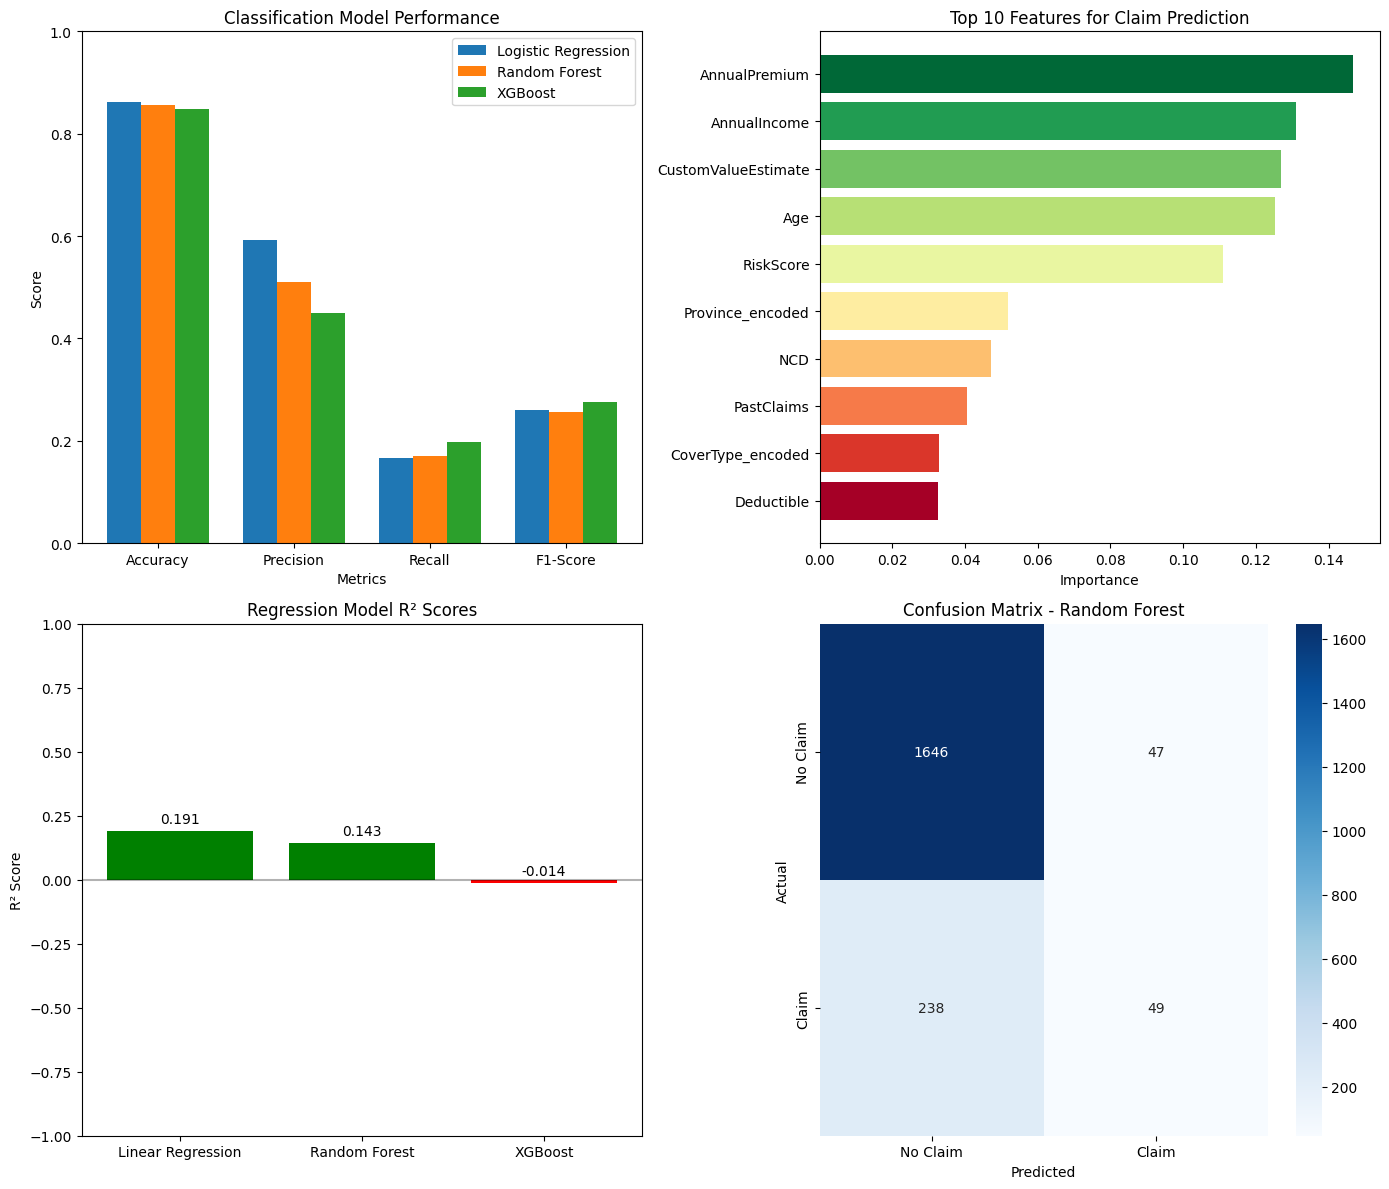

✓ Visualization saved to reports/modeling_results.png

SAVING RESULTS
✓ Classification results saved to reports/classification_results.csv
✓ Regression results saved to reports/regression_results.csv
✓ Feature importance saved to reports/feature_importance.csv

PART 6: PREMIUM OPTIMIZATION EXAMPLE
Average historical claim severity: R7,351.83
Expense loading: 15%
Profit margin: 8%
Final premium formula: Premium = P(claim) × Avg Severity × (1 + 0.15 + 0.08)

------------------------------------------------------------
SAMPLE RISK-BASED PREMIUM CALCULATIONS
------------------------------------------------------------

Policy 1:
  Claim Probability: 5.00%
  Risk Premium: R367.59
  Final Recommended Premium: R452.14

Policy 2:
  Claim Probability: 12.00%
  Risk Premium: R882.22
  Final Recommended Premium: R1,085.13

Policy 3:
  Claim Probability: 3.00%
  Risk Premium: R220.55
  Final Recommended Premium: R271.28

Policy 4:
  Claim Probability: 3.00%
  Risk Premium: R220.55
  Final Recommen

In [4]:
"""
TASK 4: STATISTICAL MODELING & RISK-BASED PRICING
AlphaCare Insurance Solutions - Week 3 Challenge
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("TASK 4: STATISTICAL MODELING & RISK-BASED PRICING")
print("="*80)

# Load data
df = pd.read_csv('../data/insurance_data_clean.csv')

# Create derived metrics
df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['Margin'] = df['TotalPremium'] - df['TotalClaims']
df['HasClaim'] = (df['TotalClaims'] > 0).astype(int)

print(f"Dataset shape: {df.shape}")
print(f"Policies with claims: {df['HasClaim'].sum()} ({df['HasClaim'].mean()*100:.2f}%)")
print(f"Policies without claims: {(df['HasClaim'] == 0).sum()} ({(1-df['HasClaim'].mean())*100:.2f}%)")

# ============================================
# FEATURE ENGINEERING
# ============================================
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

# Create new features from existing columns
df['YoungDriver'] = (df['Age'] < 25).astype(int)
df['SeniorDriver'] = (df['Age'] > 65).astype(int)
df['HighValueVehicle'] = (df['CustomValueEstimate'] > 50000).astype(int)
df['HighRisk'] = (df['RiskScore'] > 70).astype(int)
df['HighDeductible'] = (df['Deductible'] > 500).astype(int)
df['LowNCD'] = (df['NCD'] < 20).astype(int)
df['MultiplePastClaims'] = (df['PastClaims'] > 2).astype(int)
df['HighIncome'] = (df['AnnualIncome'] > 100000).astype(int)

# Select numeric features (that exist in the dataset)
numeric_features = [
    'Age', 'AnnualIncome', 'RiskScore', 'AnnualPremium', 'Deductible', 
    'NCD', 'PastClaims', 'CustomValueEstimate'
]

print(f"Numeric features: {numeric_features}")

# Categorical features
categorical_features = ['Gender', 'Province', 'VehicleType', 'CoverType']

print(f"Categorical features: {categorical_features}")

# Encode categorical variables
df_encoded = df.copy()
for col in categorical_features:
    le = LabelEncoder()
    df_encoded[col + '_encoded'] = le.fit_transform(df_encoded[col].astype(str))
    print(f"  {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Add engineered features to feature list
engineered_features = ['YoungDriver', 'SeniorDriver', 'HighValueVehicle', 'HighRisk', 
                        'HighDeductible', 'LowNCD', 'MultiplePastClaims', 'HighIncome']

# Create feature matrix
feature_columns = numeric_features + [col + '_encoded' for col in categorical_features] + engineered_features
X = df_encoded[feature_columns]
y_class = df_encoded['HasClaim']

print(f"\nTotal features: {len(feature_columns)}")
print(f"Feature matrix shape: {X.shape}")

# ============================================
# PART 1: CLAIM PROBABILITY (Classification)
# ============================================
print("\n" + "="*80)
print("PART 1: CLAIM PROBABILITY PREDICTION")
print("="*80)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y_class, test_size=0.2, random_state=42, stratify=y_class)

print(f"Training set: {len(X_train)} policies")
print(f"Test set: {len(X_test)} policies")
print(f"Training claim rate: {y_train.mean()*100:.2f}%")
print(f"Test claim rate: {y_test.mean()*100:.2f}%")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Models
classifiers = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss')
}

results_class = []

print("\nTraining Classification Models...")
print("-"*60)

for name, model in classifiers.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    results_class.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })
    
    print(f"\n{name}:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"  Recall: {recall_score(y_test, y_pred):.4f}")
    print(f"  F1-Score: {f1_score(y_test, y_pred):.4f}")

# Summary
results_class_df = pd.DataFrame(results_class)
print("\n" + "-"*60)
print("CLASSIFICATION RESULTS SUMMARY:")
print(results_class_df.to_string(index=False))

# ============================================
# PART 2: CLAIM SEVERITY (Regression)
# ============================================
print("\n" + "="*80)
print("PART 2: CLAIM SEVERITY PREDICTION")
print("="*80)

# Filter for policies with claims
claims_df = df_encoded[df_encoded['HasClaim'] == 1].copy()
print(f"Policies with claims for severity modeling: {len(claims_df)}")

if len(claims_df) > 10:
    X_sev = claims_df[feature_columns]
    y_sev = claims_df['TotalClaims']
    
    X_train_sev, X_test_sev, y_train_sev, y_test_sev = train_test_split(
        X_sev, y_sev, test_size=0.2, random_state=42
    )
    
    scaler_sev = StandardScaler()
    X_train_sev_scaled = scaler_sev.fit_transform(X_train_sev)
    X_test_sev_scaled = scaler_sev.transform(X_test_sev)
    
    regressors = {
        'Linear Regression': LinearRegression(),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'XGBoost': XGBRegressor(n_estimators=100, random_state=42)
    }
    
    results_reg = []
    
    print("\nTraining Regression Models...")
    print("-"*60)
    
    for name, model in regressors.items():
        model.fit(X_train_sev_scaled, y_train_sev)
        y_pred_sev = model.predict(X_test_sev_scaled)
        
        rmse = np.sqrt(mean_squared_error(y_test_sev, y_pred_sev))
        r2 = r2_score(y_test_sev, y_pred_sev)
        
        results_reg.append({
            'Model': name,
            'RMSE': rmse,
            'R²': r2
        })
        
        print(f"\n{name}:")
        print(f"  RMSE: {rmse:.2f}")
        print(f"  R²: {r2:.4f}")
    
    results_reg_df = pd.DataFrame(results_reg)
    print("\n" + "-"*60)
    print("REGRESSION RESULTS SUMMARY:")
    print(results_reg_df.to_string(index=False))
else:
    print("Not enough claims data for severity modeling")
    results_reg_df = pd.DataFrame()

# ============================================
# PART 3: FEATURE IMPORTANCE
# ============================================
print("\n" + "="*80)
print("PART 3: FEATURE IMPORTANCE")
print("="*80)

# Get feature importance from Random Forest
rf_model = classifiers['Random Forest']
importance_df = pd.DataFrame({
    'Feature': feature_columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\nTop 10 Most Important Features for Claim Prediction:")
for i, row in importance_df.head(10).iterrows():
    print(f"  {i+1}. {row['Feature']}: {row['Importance']:.4f}")

# ============================================
# PART 4: VISUALIZATIONS
# ============================================
print("\n" + "="*80)
print("PART 4: VISUALIZATIONS")
print("="*80)

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Classification Results
ax1 = axes[0, 0]
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, row in results_class_df.iterrows():
    values = [row[m] for m in metrics]
    ax1.bar(x + i*width, values, width, label=row['Model'])

ax1.set_xlabel('Metrics')
ax1.set_ylabel('Score')
ax1.set_title('Classification Model Performance')
ax1.set_xticks(x + width)
ax1.set_xticklabels(metrics)
ax1.legend()
ax1.set_ylim(0, 1)

# Plot 2: Feature Importance
ax2 = axes[0, 1]
top_features = importance_df.head(10)
colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(top_features)))
ax2.barh(top_features['Feature'], top_features['Importance'], color=colors)
ax2.set_xlabel('Importance')
ax2.set_title('Top 10 Features for Claim Prediction')
ax2.invert_yaxis()

# Plot 3: Regression Results (if available)
ax3 = axes[1, 0]
if len(results_reg_df) > 0:
    models = results_reg_df['Model'].tolist()
    r2_scores = results_reg_df['R²'].tolist()
    colors_r2 = ['green' if r2 > 0 else 'red' for r2 in r2_scores]
    bars = ax3.bar(models, r2_scores, color=colors_r2)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.3)
    ax3.set_ylabel('R² Score')
    ax3.set_title('Regression Model R² Scores')
    ax3.set_ylim(-1, 1)
    # Add value labels on bars
    for bar, r2 in zip(bars, r2_scores):
        ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02, 
                f'{r2:.3f}', ha='center', va='bottom')
else:
    ax3.text(0.5, 0.5, 'No regression results available', ha='center', va='center')
    ax3.set_title('Regression Results')

# Plot 4: Confusion Matrix for Best Classifier
ax4 = axes[1, 1]
best_model = classifiers['Random Forest']
y_pred_best = best_model.predict(X_test_scaled)
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax4)
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_title('Confusion Matrix - Random Forest')
ax4.set_xticklabels(['No Claim', 'Claim'])
ax4.set_yticklabels(['No Claim', 'Claim'])

plt.tight_layout()
plt.savefig('reports/modeling_results.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Visualization saved to reports/modeling_results.png")

# ============================================
# PART 5: SAVE RESULTS
# ============================================
print("\n" + "="*80)
print("SAVING RESULTS")
print("="*80)

import os
os.makedirs('reports', exist_ok=True)

results_class_df.to_csv('reports/classification_results.csv', index=False)
print("✓ Classification results saved to reports/classification_results.csv")

if len(results_reg_df) > 0:
    results_reg_df.to_csv('reports/regression_results.csv', index=False)
    print("✓ Regression results saved to reports/regression_results.csv")

importance_df.to_csv('reports/feature_importance.csv', index=False)
print("✓ Feature importance saved to reports/feature_importance.csv")

# ============================================
# PART 6: PREMIUM OPTIMIZATION EXAMPLE
# ============================================
print("\n" + "="*80)
print("PART 6: PREMIUM OPTIMIZATION EXAMPLE")
print("="*80)

# Get claim probabilities from best model
best_model = classifiers['Random Forest']
claim_probs = best_model.predict_proba(X_test_scaled)[:, 1]

# Calculate average severity from historical claims
if len(claims_df) > 0:
    avg_severity = claims_df['TotalClaims'].mean()
else:
    avg_severity = 5000

print(f"Average historical claim severity: R{avg_severity:,.2f}")
print(f"Expense loading: 15%")
print(f"Profit margin: 8%")
print(f"Final premium formula: Premium = P(claim) × Avg Severity × (1 + 0.15 + 0.08)")

# Example calculations for 5 sample policies
print("\n" + "-"*60)
print("SAMPLE RISK-BASED PREMIUM CALCULATIONS")
print("-"*60)

sample_indices = np.random.choice(len(X_test), min(5, len(X_test)), replace=False)

for i, idx in enumerate(sample_indices):
    prob = claim_probs[idx]
    
    # Premium formula
    expense_rate = 0.15
    profit_margin = 0.08
    risk_premium = prob * avg_severity
    total_premium = risk_premium * (1 + expense_rate + profit_margin)
    
    print(f"\nPolicy {i+1}:")
    print(f"  Claim Probability: {prob*100:.2f}%")
    print(f"  Risk Premium: R{risk_premium:,.2f}")
    print(f"  Final Recommended Premium: R{total_premium:,.2f}")

print("\n" + "="*80)
print("TASK 4 COMPLETED SUCCESSFULLY!")
print("="*80)